# Probability in the Wild: Are Major Earthquakes Poisson?

We will use **real USGS earthquake data** to ask a statistical question:

$$
\boxed{\text{Can the number of major earthquakes per month be modeled by a Poisson distribution?}}
$$

$$
\boxed{\text{When can we model them using Gaussian distribution over Poisson distribution and vice-versa ?}}
$$

By the end, we will have used:

- a real dataset,
- a discrete random variable,
- an empirical PMF and CDF,
- expectation and variance,
- the Poisson model,
- and, most importantly, the **assumptions behind the model**.

The point is not to prove that earthquakes *are* Poisson. The point is to ask whether the model is a useful description of the data.

In [57]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Try changing MAG_MIN after completing the notebook.
START_DATE = "1900-01-01"
END_DATE   = "2025-12-31"
MAG_MIN    = 6.85 ## I found that the value below 5.8 crashes the i/o.

print(f"Studying earthquakes with magnitude >= {MAG_MIN}")
print(f"Time period: {START_DATE} to {END_DATE}")

Studying earthquakes with magnitude >= 6.85
Time period: 1900-01-01 to 2025-12-31


## Before looking at the data

Let

$$
X_m = \text{number of earthquakes with magnitude } \ge 6.5
\text{ occurring in month }m.
$$

If

$$
X_m \sim \operatorname{Poisson}(\lambda),
$$

then Lecture 3 tells us

$$
\mathbb E[X_m] = \lambda,
\qquad
\operatorname{Var}(X_m)=\lambda.
$$

So a very simple first diagnostic is:

$$
\boxed{\text{Is the empirical mean approximately equal to the empirical variance?}}
$$

**Prediction:** Before running the next cells, do you expect the Poisson model to work well? Why or why not?

In [58]:
# Cell 2: Download real earthquake data from the USGS catalog
from urllib.parse import urlencode

params = {
    "format": "csv",
    "starttime": START_DATE,
    "endtime": END_DATE,
    "minmagnitude": MAG_MIN,
    "orderby": "time-asc",
}

base_url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
url = base_url + "?" + urlencode(params)

try:
    earthquakes = pd.read_csv(url)
except Exception as e:
    raise RuntimeError(
        "Could not download the USGS data. Check your internet connection "
        "and try again.\n\nUSGS query:\n" + url
    ) from e

earthquakes["time"] = pd.to_datetime(earthquakes["time"], utc=True)

print(f"Number of earthquakes: {len(earthquakes)}")
earthquakes[["time", "mag", "place"]].head()

Number of earthquakes: 2117


/tmp/ipykernel_142898/2634050454.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  earthquakes["time"] = pd.to_datetime(earthquakes["time"], utc=True)


,time,mag,place
0,1900-01-05 19:00:00+00:00,7.0,"Southern Sumatra, Indonesia"
1,1900-01-11 09:07:00+00:00,7.0,Bismarck Sea
2,1900-01-20 06:33:00+00:00,7.3,"Jalisco, Mexico"
3,1900-01-31 19:22:00+00:00,7.5,Sea of Okhotsk
4,1900-05-11 17:23:00+00:00,7.0,"Northern Honshu, Japan"


1900-01-01 00:00:00+00:00    4
1900-02-01 00:00:00+00:00    0
1900-03-01 00:00:00+00:00    0
1900-04-01 00:00:00+00:00    0
1900-05-01 00:00:00+00:00    1
Freq: MS, Name: earthquakes, dtype: int64

Number of months: 1512


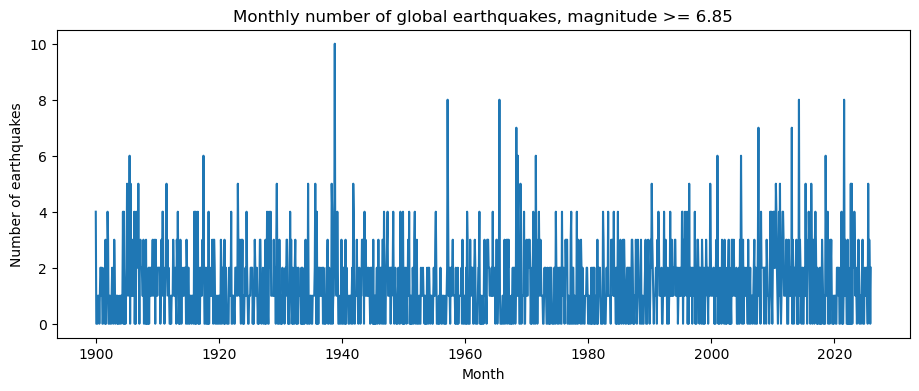

In [59]:
# Cell 3: Turn earthquake times into MONTHLY COUNTS

# Count how many earthquakes occur in each calendar month.
monthly_counts = (
    earthquakes
    .set_index("time")
    .resample("MS")
    .size()
)

# Important: months with ZERO earthquakes must also be included.
all_months = pd.date_range(
    start=START_DATE,
    end=END_DATE,
    freq="MS",
    tz="UTC"
)

monthly_counts = monthly_counts.reindex(all_months, fill_value=0)
monthly_counts.name = "earthquakes"

print(monthly_counts.head())
print(f"\nNumber of months: {len(monthly_counts)}")

# First visualization: the random variable observed through time.
plt.figure(figsize=(11, 4))
plt.plot(monthly_counts.index, monthly_counts.values)
plt.xlabel("Month")
plt.ylabel("Number of earthquakes")
plt.title(f"Monthly number of global earthquakes, magnitude >= {MAG_MIN}")
plt.show()

In [60]:
monthly_counts.index, monthly_counts.values

(DatetimeIndex(['1900-01-01 00:00:00+00:00', '1900-02-01 00:00:00+00:00',
                '1900-03-01 00:00:00+00:00', '1900-04-01 00:00:00+00:00',
                '1900-05-01 00:00:00+00:00', '1900-06-01 00:00:00+00:00',
                '1900-07-01 00:00:00+00:00', '1900-08-01 00:00:00+00:00',
                '1900-09-01 00:00:00+00:00', '1900-10-01 00:00:00+00:00',
                ...
                '2025-03-01 00:00:00+00:00', '2025-04-01 00:00:00+00:00',
                '2025-05-01 00:00:00+00:00', '2025-06-01 00:00:00+00:00',
                '2025-07-01 00:00:00+00:00', '2025-08-01 00:00:00+00:00',
                '2025-09-01 00:00:00+00:00', '2025-10-01 00:00:00+00:00',
                '2025-11-01 00:00:00+00:00', '2025-12-01 00:00:00+00:00'],
               dtype='datetime64[ns, UTC]', length=1512, freq='MS'),
 array([4, 0, 0, ..., 2, 0, 2]))

## Pay close attention to the mean and variance of the data.. 
## Does it tell you something about the distribution ?

Empirical mean     = 1.400
Empirical variance = 1.765
Variance / mean    = 1.261


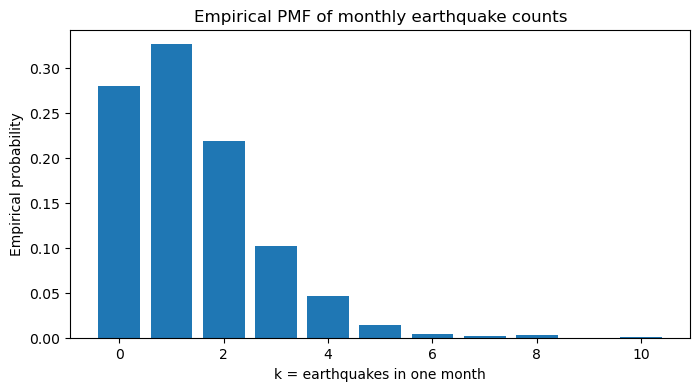

Question: If the data were exactly Poisson, what relationship
would you expect between the mean and variance?


In [61]:
# Cell 4: Build the EMPIRICAL probability distribution
mean_count = monthly_counts.mean()

# ddof=0 treats the observed months as the empirical distribution itself.
variance_count = monthly_counts.var(ddof=0)

print(f"Empirical mean     = {mean_count:.3f}")
print(f"Empirical variance = {variance_count:.3f}")
print(f"Variance / mean    = {variance_count / mean_count:.3f}")

# Possible monthly counts k = 0, 1, 2, ...
k_max = max(
    int(monthly_counts.max()),
    int(np.ceil(mean_count + 5*np.sqrt(mean_count)))
)
k = np.arange(k_max + 1)

empirical_pmf = (
    monthly_counts
    .value_counts(normalize=True)
    .reindex(k, fill_value=0)
    .sort_index()
)

plt.figure(figsize=(8, 4))
plt.bar(k, empirical_pmf.values)
plt.xlabel("k = earthquakes in one month")
plt.ylabel("Empirical probability")
plt.title("Empirical PMF of monthly earthquake counts")
plt.show()

print("Question: If the data were exactly Poisson, what relationship")
print("would you expect between the mean and variance?")

## Now fit the simplest possible Poisson model

For a Poisson random variable,

$$
P(X=k)=e^{-\lambda}\frac{\lambda^k}{k!}.
$$

Because

$$
\mathbb E[X]=\lambda,
$$

a natural estimate from the data is simply

$$
\boxed{\hat\lambda=\bar X}.
$$

There is no complicated fitting algorithm here: **the sample mean determines the fitted Poisson distribution.**

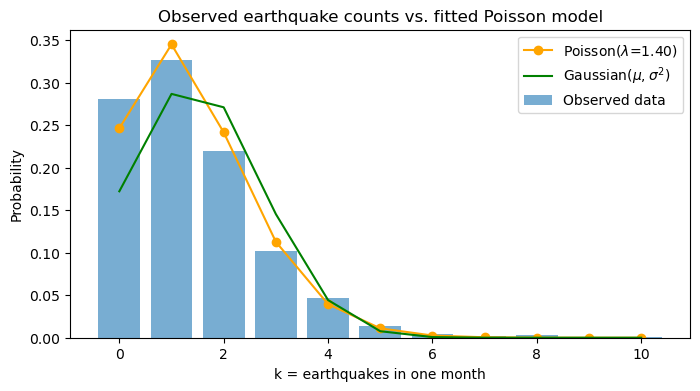

,k,empirical_P(X=k),poisson_P(X=k)
0,0,0.280423,0.246564
1,1,0.326720,0.345223
2,2,0.219577,0.241679
3,3,0.102513,0.112794
4,4,0.046958,0.039482
5,5,0.013889,0.011056
6,6,0.004630,0.002580
7,7,0.001984,0.000516
8,8,0.002646,0.000090
9,9,0.000000,0.000014


In [62]:
# Cell 5: Compare the empirical PMF with Poisson(lambda_hat)
lambda_hat = mean_count

factorials = np.array([math.factorial(int(x)) for x in k], dtype=float)
poisson_pmf = np.exp(-lambda_hat) * lambda_hat**k / factorials
std_count = np.sqrt(variance_count);
norm_const = (1./(np.sqrt(2*np.pi)*std_count))
gaussian_pmf = norm_const*np.exp( - ((k - mean_count)**2)/(2*variance_count) )

plt.figure(figsize=(8, 4))
plt.bar(k, empirical_pmf.values, alpha=0.6, label="Observed data")
plt.plot(k, poisson_pmf, marker="o", color='orange',label=f"Poisson($\\lambda$={lambda_hat:.2f})")
plt.plot(k, gaussian_pmf, '-', color='green', label=f"Gaussian($\mu,\sigma^2)$")

plt.xlabel("k = earthquakes in one month")
plt.ylabel("Probability")
plt.title("Observed earthquake counts vs. fitted Poisson model")
plt.legend()
plt.show()

comparison = pd.DataFrame({
    "k": k,
    "empirical_P(X=k)": empirical_pmf.values,
    "poisson_P(X=k)": poisson_pmf,
})

comparison.head(12)

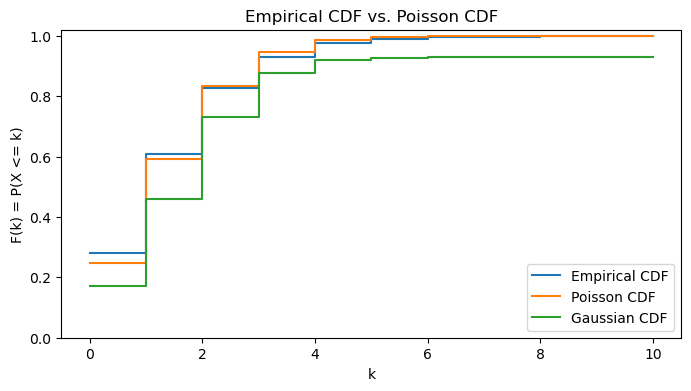

Observed P(X <= 5) = 0.990
Poisson  P(X <= 5) = 0.997


In [63]:
# Cell 6: Compare the CDFs

# Recall: F(k) = P(X <= k)
empirical_cdf = np.cumsum(empirical_pmf.values)
poisson_cdf = np.cumsum(poisson_pmf)
gaussian_cdf = np.cumsum(gaussian_pmf)

plt.figure(figsize=(8, 4))
plt.step(k, empirical_cdf, where="post", label="Empirical CDF")
plt.step(k, poisson_cdf, where="post", label="Poisson CDF")
plt.step(k, gaussian_cdf, where="post", label="Gaussian CDF")
plt.xlabel("k")
plt.ylabel("F(k) = P(X <= k)")
plt.title("Empirical CDF vs. Poisson CDF")
plt.ylim(0, 1.02)
plt.legend()
plt.show()

# One concrete probability question:
cutoff = 5
empirical_prob = np.mean(monthly_counts <= cutoff)
poisson_prob = poisson_cdf[cutoff] if cutoff < len(poisson_cdf) else np.nan

print(f"Observed P(X <= {cutoff}) = {empirical_prob:.3f}")
print(f"Poisson  P(X <= {cutoff}) = {poisson_prob:.3f}")

In [64]:
# Cell 7: Where does the Poisson model struggle?

# The Poisson model assumes, approximately:
#   1. events occur independently,
#   2. the average rate is roughly constant.
#
# Look at the months with unusually many earthquakes.

top_months = monthly_counts.sort_values(ascending=False).head(5)

print("Five months with the largest earthquake counts:")
display(top_months.to_frame())

top_month = top_months.index[0]
next_month = top_month + pd.offsets.MonthBegin(1)

events_in_top_month = earthquakes[
    (earthquakes["time"] >= top_month) &
    (earthquakes["time"] < next_month)
][["time", "mag", "place"]].sort_values("time")

print(f"\nEarthquakes during the highest-count month: {top_month.strftime('%B %Y')}")
display(events_in_top_month)

print("\nDISCUSSION")
print("1. Do several events occur close together in time?")
print("2. Do the locations suggest that some events may be related?")
print("3. If aftershocks occur, is the independence assumption reasonable?")
print("4. Is a constant-rate Poisson model still a useful first approximation?")
print("5. Try MAG_MIN = 6.0, 6.5, and 7.0. What changes?")

Five months with the largest earthquake counts:


,earthquakes
1938-11-01 00:00:00+00:00,10
2014-04-01 00:00:00+00:00,8
1957-03-01 00:00:00+00:00,8
2021-08-01 00:00:00+00:00,8
1965-08-01 00:00:00+00:00,8



Earthquakes during the highest-count month: November 1938


,time,mag,place
637,1938-11-05 08:43:24.230000+00:00,7.80,"105 km E of Iwaki, Japan"
638,1938-11-05 10:50:18.100000+00:00,7.70,"116 km ESE of Namie, Japan"
639,1938-11-06 08:53:55.300000+00:00,7.70,"116 km E of Namie, Japan"
640,1938-11-06 21:38:47.220000+00:00,7.60,"141 km ESE of Namie, Japan"
641,1938-11-09 09:15:54.300000+00:00,6.90,"174 km ESE of Iwaki, Japan"
642,1938-11-10 20:18:49+00:00,8.23,"1938 Semidi Islands, Alaska Earthquake"
643,1938-11-13 22:31:31.120000+00:00,7.11,"200 km ESE of Iwaki, Japan"
644,1938-11-17 03:54:41.190000+00:00,6.90,"105 km ESE of Perryville, Alaska"
645,1938-11-22 01:14:05.170000+00:00,6.85,"155 km ESE of Iwaki, Japan"
646,1938-11-30 02:29:51.350000+00:00,7.04,"99 km E of Iwaki, Japan"



DISCUSSION
1. Do several events occur close together in time?
2. Do the locations suggest that some events may be related?
3. If aftershocks occur, is the independence assumption reasonable?
4. Is a constant-rate Poisson model still a useful first approximation?
5. Try MAG_MIN = 6.0, 6.5, and 7.0. What changes?
